In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [ ]:
# Download latest version
path = kagglehub.dataset_download("muradamn/ibm-hr-analytics-employee-attrition-datase")

print("Path to dataset files:", path)

100%|██████████| 50.1k/50.1k [00:00<00:00, 27.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muradamn/ibm-hr-analytics-employee-attrition-datase/versions/1


In [ ]:
file = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(file)

df.head().T

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,Yes,No,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,1102,279,1373,1392,591
Department,Sales,Research & Development,Research & Development,Research & Development,Research & Development
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,Life Sciences,Life Sciences,Other,Life Sciences,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
num_df = df.select_dtypes(include=np.number)

stats_df = num_df.describe().T
stats_df["skewness"] = num_df.skew()
stats_df["kurtosis"] = num_df.kurt()

stats_df

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0,0.413286,-0.404145
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0,-0.003519,-1.203823
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0,0.958118,-0.224833
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0,-0.289681,-0.559115
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0,0.000000,0.000000
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0,0.016574,-1.223179
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0,-0.321654,-1.202521
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0,-0.032311,-1.196398
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0,-0.498419,0.270999
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0,1.025401,0.399152


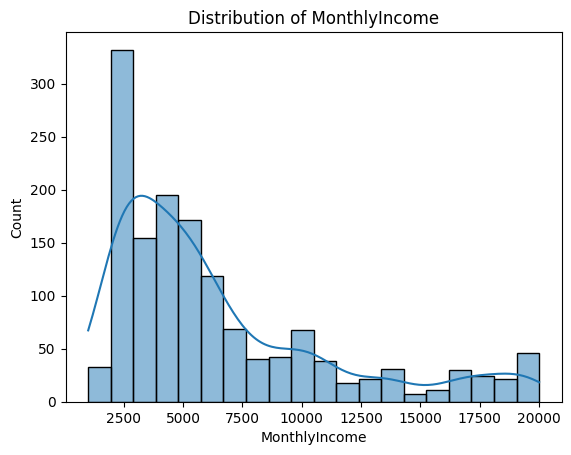

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

feature = "MonthlyIncome"  # change as needed

sns.histplot(df[feature], kde=True)
plt.title(f"Distribution of {feature}")
plt.show()

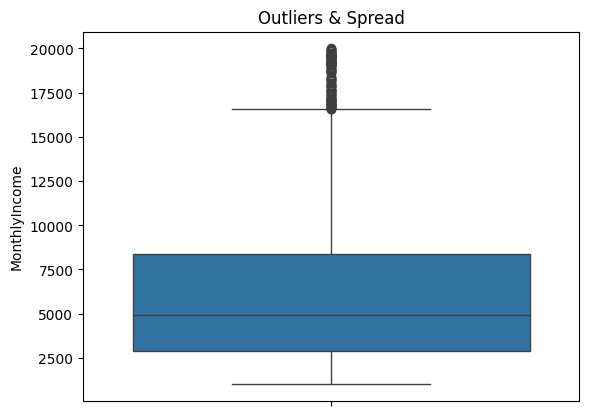

In [ ]:
sns.boxplot(y=df["MonthlyIncome"])
plt.title("Outliers & Spread")
plt.show()

In [ ]:
# -----------------------
# TARGET ENCODING
# -----------------------
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

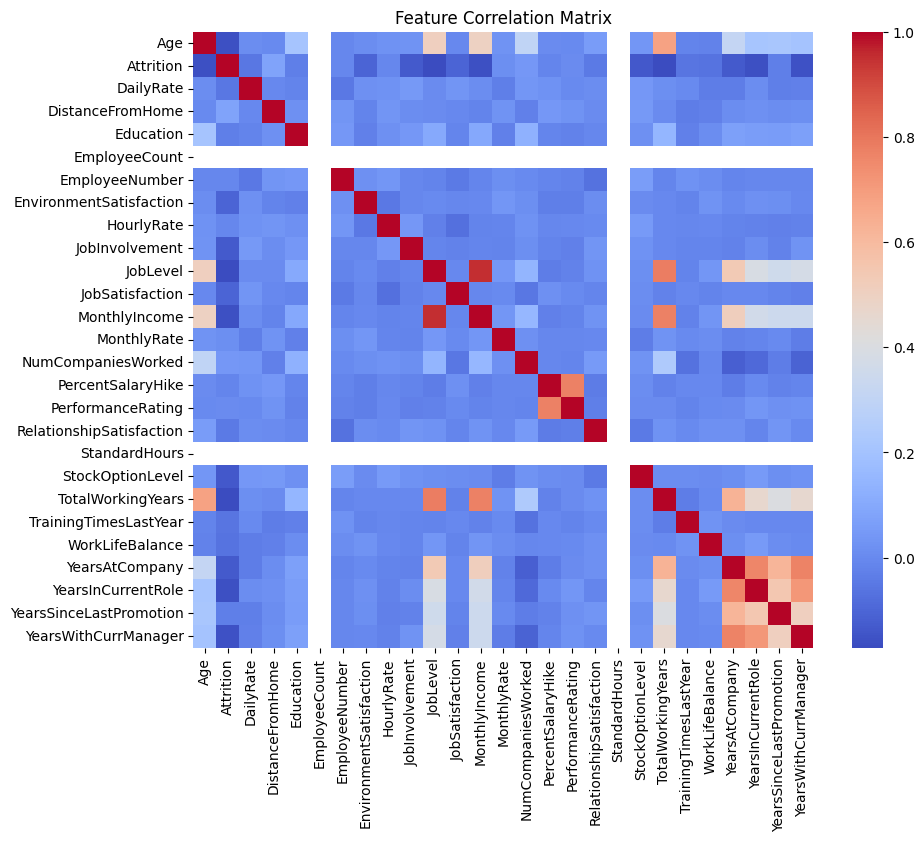

In [ ]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# -----------------------
# CHI-SQUARE TEST (categorical vs target)
# -----------------------
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    contingency = pd.crosstab(df[col], df["Attrition"])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)
    print(f"{col}: p-value = {p}")

BusinessTravel: p-value = 5.608614476449931e-06
Department: p-value = 0.004525606574479633
EducationField: p-value = 0.006773980139025212
Gender: p-value = 0.29057244902890855
JobRole: p-value = 2.752481638050657e-15
MaritalStatus: p-value = 9.45551106034083e-11
Over18: p-value = 1.0
OverTime: p-value = 8.15842372153832e-21


In [ ]:
# -----------------------
# LABEL ENCODING
# -----------------------
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.head().T

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,1,0,1,0,0
BusinessTravel,2,1,2,1,2
DailyRate,1102,279,1373,1392,591
Department,2,1,1,1,1
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,1,1,4,1,3
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


In [ ]:
df.drop(["EmployeeCount", "PerformanceRating", "Over18", "MonthlyRate","DailyRate", "EmployeeNumber"], axis=1, inplace=True)

In [ ]:
df.drop(["StandardHours", "DistanceFromHome"], axis=1, inplace=True)

In [ ]:
df.head().T

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,1,0,1,0,0
BusinessTravel,2,1,2,1,2
Department,2,1,1,1,1
Education,2,1,2,4,1
EducationField,1,1,4,1,3
EnvironmentSatisfaction,2,3,4,4,1
Gender,0,1,1,0,1
HourlyRate,94,61,92,56,40
JobInvolvement,3,2,2,3,3


In [ ]:
# -----------------------
# FEATURES & TARGET
# -----------------------
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# -----------------------
# TRAIN TEST SPLIT
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------
# STANDARDIZATION
# -----------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------
# LOGISTIC REGRESSION (PROBABILITY MODEL)
# -----------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

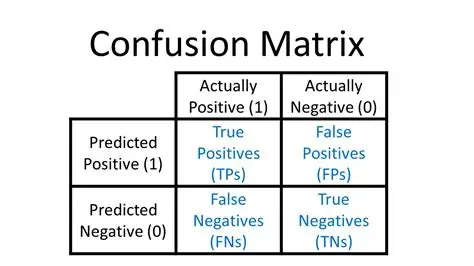

In [ ]:
# -----------------------
# EVALUATION (STATISTICS)
# -----------------------
print("\nCONFUSION MATRIX:\n", confusion_matrix(y_test, y_pred))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))




CONFUSION MATRIX:
 [[241   6]
 [ 28  19]]

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.90      0.98      0.93       247
           1       0.76      0.40      0.53        47

    accuracy                           0.88       294
   macro avg       0.83      0.69      0.73       294
weighted avg       0.87      0.88      0.87       294


ROC-AUC: 0.8100611594452579


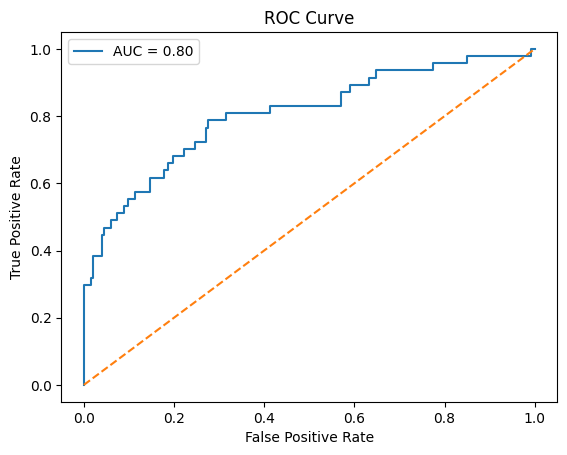

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# -----------------------
# COEFFICIENTS + ODDS RATIOS
# -----------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
}).sort_values(by="Odds_Ratio", ascending=False)

print("\nTOP DRIVERS OF ATTRITION:\n", coef_df.head(10))



TOP DRIVERS OF ATTRITION:
                     Feature  Coefficient  Odds_Ratio
21                 OverTime     0.782163    2.186196
32  YearsSinceLastPromotion     0.481498    1.618496
3                Department     0.470444    1.600705
19       NumCompaniesWorked     0.449615    1.567708
4          DistanceFromHome     0.313663    1.368428
16            MaritalStatus     0.293921    1.341679
30           YearsAtCompany     0.238770    1.269686
23        PerformanceRating     0.143405    1.154197
10                   Gender     0.141015    1.151442
5                 Education     0.033477    1.034043


In [ ]:

# -----------------------
# CONFIDENCE INTERVALS (APPROX)
# -----------------------
std_err = np.std(X_train, axis=0)
ci_lower = model.coef_[0] - 1.96 * std_err
ci_upper = model.coef_[0] + 1.96 * std_err

ci_df = pd.DataFrame({
    "Feature": X.columns,
    "Coef": model.coef_[0],
    "CI_Lower": ci_lower,
    "CI_Upper": ci_upper
})

print("\nCONFIDENCE INTERVALS (approx):\n", ci_df.head())


CONFIDENCE INTERVALS (approx):
             Feature      Coef  CI_Lower  CI_Upper
0               Age -0.410156 -2.370156  1.549844
1    BusinessTravel -0.021499 -1.981499  1.938501
2         DailyRate -0.188320 -2.148320  1.771680
3        Department  0.470444 -1.489556  2.430444
4  DistanceFromHome  0.313663 -1.646337  2.273663
